# 02 - Logistic regression from zero

Phase 2, part 1. Here we build the simplest model: **one neuron**.

The task is binary. We only keep two classes:

- **N** = normal beat
- **V** = ventricular beat, it starts in the bottom of the heart and has a wide shape

The goal of this notebook is not a high score. The goal is to make the maths work
and to check it against a library that we trust.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from ecg.config import Config
from ecg.data import load_split, class_names
from ecg.metrics import report, macro_f1, accuracy, majority_baseline, confusion_matrix
from ecg import plots

## 1. Load the data and find the floor

Before any model, we need to know what "doing nothing" gives us.
Most beats are normal, so a lazy model can just say "normal" every time and still
look good. That number is our floor.

In [2]:
Xtr, ytr, rec_tr = load_split("train", classes="NV", columns=True)
Xdv, ydv, rec_dv = load_split("dev", classes="NV", columns=True)

print("train:", Xtr.shape, " dev:", Xdv.shape)
print("train N =", int((ytr == 0).sum()), " V =", int((ytr == 1).sum()))
print("dev   N =", int((ydv == 0).sum()), " V =", int((ydv == 1).sum()))

train: (254, 39388)  dev: (254, 10248)
train N = 36418  V = 2970
dev   N = 9430  V = 818


In [3]:
always_normal = np.zeros_like(ytr)
print("IF WE ALWAYS SAY NORMAL:")
print(report(ytr, always_normal, class_names("NV")))

IF WE ALWAYS SAY NORMAL:
 class     prec   recall       f1  support
     N    0.925    1.000    0.961    36418
     V    0.000    0.000    0.000     2970

  accuracy  0.9246   (baseline 0.9246)
  macro-F1  0.4804


Look at the two numbers at the bottom.

- **Accuracy is 0.92**, that looks very good, but the model learned nothing.
- **Macro-F1 is 0.48**, and this one tells the truth.

Macro-F1 takes the F1 of each class and makes a simple average. Class V gets an F1
of 0, so the average drops. This is why we use macro-F1 in this project and not
accuracy.

**We must beat 0.48.**

## 2. Train the neuron

One neuron does three things:

1. multiply the input by weights `w` and add a bias `b`
2. push the answer through a sigmoid, so it becomes a probability between 0 and 1
3. compare with the true label and move `w` and `b` a little in the better direction

We repeat step 3 many times. This is gradient descent.

The code is in `src/ecg/logistic.py`.

In [4]:
from ecg.logistic import fit, predict

result = fit(Xtr, ytr, num_iterations=2000, learning_rate=0.5, print_every=400)

pred_tr = predict(result["w"], result["b"], Xtr)
pred_dv = predict(result["w"], result["b"], Xdv)

iteration 0  loss 0.693147


iteration 400  loss 0.054853


iteration 800  loss 0.048707


iteration 1200  loss 0.045254


iteration 1600  loss 0.042945


saved C:\Users\WellCome\Desktop\Courses\DeepLearningSpecialization\projects\ECG\results\figures\phase2_logistic_loss.png


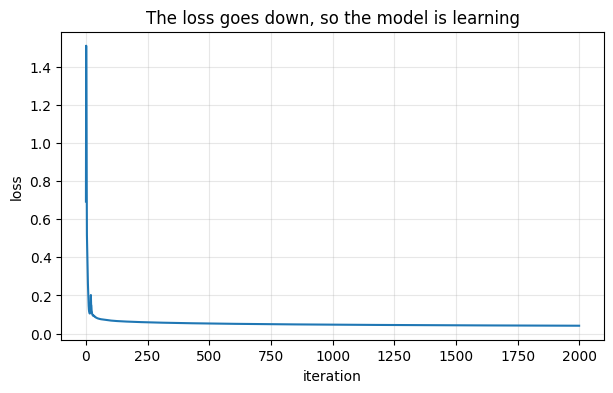

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(result["costs"])
ax.set_xlabel("iteration")
ax.set_ylabel("loss")
ax.set_title("The loss goes down, so the model is learning")
ax.grid(alpha=0.3)
plots.save(fig, "phase2_logistic_loss")
plt.show()

## 3. Check against scikit-learn

This is the important part of the notebook.

We wrote the maths ourselves, so we can easily make a mistake. scikit-learn solves
the same problem with a better method. If our answer is close to theirs, our maths
is probably right.

We ask scikit-learn for `penalty=None`. By default it adds regularisation, and then
it would be solving a different problem, so the comparison would not be fair.

In [6]:
from sklearn.linear_model import LogisticRegression

sk = LogisticRegression(penalty=None, max_iter=2000)
sk.fit(Xtr.T, ytr.ravel())
sk_tr = sk.predict(Xtr.T)
sk_dv = sk.predict(Xdv.T)

gap = abs(accuracy(ytr, pred_tr) - accuracy(ytr, sk_tr))

print("               ours    sklearn     gap")
print("train acc   %.4f     %.4f   %.4f" % (accuracy(ytr, pred_tr), accuracy(ytr, sk_tr), gap))
print("dev acc     %.4f     %.4f" % (accuracy(ydv, pred_dv), accuracy(ydv, sk_dv)))
print("dev mF1     %.4f     %.4f" % (macro_f1(ydv, pred_dv, 2), macro_f1(ydv, sk_dv, 2)))
print()
print("the two models agree on %.2f%% of training beats" % (100 * (pred_tr == sk_tr).mean()))
print("GATE (gap must be under 0.01):", "PASS" if gap < 0.01 else "FAIL")

               ours    sklearn     gap
train acc   0.9893     0.9916   0.0023
dev acc     0.8787     0.8881
dev mF1     0.5888     0.6132

the two models agree on 99.34% of training beats
GATE (gap must be under 0.01): PASS


## 4. What we learned

Look at the dev numbers, not the train numbers.

In [7]:
print("OUR MODEL ON DEV:")
print(report(ydv, pred_dv, class_names("NV")))

OUR MODEL ON DEV:
 class     prec   recall       f1  support
     N    0.934    0.934    0.934     9430
     V    0.242    0.244    0.243      818

  accuracy  0.8787   (baseline 0.9202)
  macro-F1  0.5888


Two things are surprising here, and both are important.

**First, dev accuracy went DOWN.** The lazy model had 0.92 and our trained model has
about 0.88. But macro-F1 went **up**, from 0.48 to about 0.59. The model now finds
some V beats, and it pays for that with a few wrong answers on normal beats. This is
a better model, even if accuracy says the opposite. This is exactly why we chose
macro-F1 at the start.

**Second, train is much better than dev.** On train we get about 0.96 macro-F1, on
dev only about 0.59. The reason is our split: train and dev contain **different
patients**. The model learns the hearts it saw, and a new heart is harder. If we had
split the beats randomly, both numbers would be near 0.99 and we would learn nothing
from them.